# EDA Completa — National Highway Planning Network (NHPN)

### Autor: Lucca Maximus Romagnolli Soares — Universidade de Brasília

## Objetivo

Realizar uma análise exploratória completa do dataset `NTAD_National_Highway_Planning_Network_-129350642200434263.csv`, com foco em:

- extensão por categoria funcional (`F_SYSTEM`)
- densidade da malha por estado (nomes dos estados)
- corredores principais (`SIGN1`/`SIGNT1`)
- participação do NHS (`NHS`)
- consistência entre `MILES`, `KM` e `Shape__Length`
- sugestões de aplicações práticas para engenharia e planejamento

## Datacard da Base `NHPN`

### 1) Identificação
- **Nome da base:** National Highway Planning Network (NHPN)
- **Arquivo analisado:** `NTAD_National_Highway_Planning_Network_-129350642200434263.csv`
- **Unidade de análise:** trecho viário (segmento de rodovia)
- **Escala geográfica:** Estados Unidos (agregado por estado via `STFIPS`)
- **Ano de referência principal:** coluna `YEAR_RECOR` (ano de registro do trecho)

### 2) Estrutura e volume
- **Total de linhas:** 626.366
- **Total de colunas:** 46
- **Tipos de dado predominantes:** numérico (inteiro/float) e categórico (códigos e classes)
- **Chaves técnicas de apoio:** `OBJECTID`, `ROUTE_ID`, `RECID`, `ORIGID`, `LRSKEY`

### 3) Principais grupos de variáveis
- **Classificação funcional:** `F_SYSTEM`, `FCLASS`, `STATUS`
- **Localização administrativa:** `STFIPS` (estado), `CTFIPS` (county)
- **Sinalização e corredor:** `SIGN1`, `SIGNT1`, `SIGNN1`, `SIGNQ1` (e pares 2/3)
- **Extensão:** `MILES`, `KM`, `Shape__Length`
- **Rede estratégica:** `NHS`, `STRAHNET`
- **Contexto urbano/rural:** `URBAN_CODE`, `RUCODE`, `LGURB`, `SMURB`

### 4) Dicionário resumido (colunas-chave)
- `STFIPS`: código FIPS do estado (neste notebook convertido para nome do estado nas visualizações)
- `CTFIPS`: código FIPS do condado
- `F_SYSTEM`: classe funcional da via (ex.: Interstate, Other Principal Arterial etc.)
- `SIGNT1`: tipo de sinalização principal (ex.: `I`, `US`, `S`)
- `SIGN1`: identificador da rota sinalizada (ex.: I-95, US-1)
- `MILES`: extensão do trecho em milhas
- `KM`: extensão do trecho em quilômetros
- `Shape__Length`: comprimento geométrico da feição linear na base original
- `NHS`: indicador de participação no National Highway System

### 5) Qualidade e limitações
- A base possui colunas com códigos técnicos que exigem mapeamento para interpretação humana.
- Para análises geoespaciais de rede (conectividade, caminho, topologia), o ideal é integrar com a geometria vetorial original (shapefile/geojson).
- `MILES`, `KM` e `Shape__Length` devem ser sempre auditados para consistência em pipelines de atualização.

### 6) Uso recomendado nesta EDA
- **Pergunta 1:** Como a extensão da malha se distribui por classe funcional?
- **Pergunta 2:** Quais estados concentram maior extensão de rodovias?
- **Pergunta 3:** Qual o peso de corredores principais (`I/US`) e do `NHS`?
- **Pergunta 4:** Os campos de comprimento estão coerentes entre si?

## Importação das bibliotecas e configuração

In [76]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Resolve a raiz do projeto de forma robusta
_raiz_atual = Path.cwd().resolve()
PROJETO_RAIZ = next((p for p in [_raiz_atual, *_raiz_atual.parents] if (p / 'datasets').exists()), _raiz_atual)

DATA_PATH = PROJETO_RAIZ / 'datasets' / 'NTAD_National_Highway_Planning_Network_-129350642200434263.csv'
print('PROJETO_RAIZ:', PROJETO_RAIZ)
print('DATA_PATH:', DATA_PATH)

# Mapeamentos para converter STFIPS em abreviacao e nome do estado
fips_to_abbr = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC',
    12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS',
    21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY',
    37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC',
    46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY', 72: 'PR'
}

fips_to_state = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California', 8: 'Colorado',
    9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia', 12: 'Florida', 13: 'Georgia',
    15: 'Hawaii', 16: 'Idaho', 17: 'Illinois', 18: 'Indiana', 19: 'Iowa', 20: 'Kansas',
    21: 'Kentucky', 22: 'Louisiana', 23: 'Maine', 24: 'Maryland', 25: 'Massachusetts',
    26: 'Michigan', 27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey', 35: 'New Mexico',
    36: 'New York', 37: 'North Carolina', 38: 'North Dakota', 39: 'Ohio', 40: 'Oklahoma',
    41: 'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island', 45: 'South Carolina',
    46: 'South Dakota', 47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont',
    51: 'Virginia', 53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming',
    72: 'Puerto Rico'
}

PROJETO_RAIZ: C:\Users\luccasoares\Desktop\Civil-Engineering
DATA_PATH: C:\Users\luccasoares\Desktop\Civil-Engineering\datasets\NTAD_National_Highway_Planning_Network_-129350642200434263.csv


## Carregamento e visão geral da base

In [33]:
df = pd.read_csv(DATA_PATH)

print(f'Linhas: {len(df):,}')
print(f'Colunas: {df.shape[1]}')

display(df.head(3))
display(df.info())

Linhas: 626,366
Colunas: 46


,OBJECTID,YEAR_RECOR,ROUTE_ID,BEGIN_POIN,END_POINT,F_SYSTEM,FACILITY_T,URBAN_CODE,RECTYPE,VERSION,RECID,ORIGID,CTFIPS,SOURCE,LGURB,SMURB,SIGN1,SIGNT1,SIGNN1,SIGNQ1,SIGN2,SIGNT2,SIGNN2,SIGNQ2,SIGN3,SIGNT3,SIGNN3,SIGNQ3,LNAME,MILES,KM,FCLASS,RUCODE,STATUS,NHS,STRAHNET,FAC_ID,CONN_ID,CONN_DES,CONN_MILES,LRSKEY,LRSSEQ,BEGMP,ENDMP,STFIPS,Shape__Length
0,1,2011,150000,157.020,176.061,3,2,99999,L,"2,014.050",2002148,2002148,290,H,0,0,S65,S,65,,,,,,,,,,JAMES DALTON HWY,18.070,29.081,2,1,1,7,0,,,,0.000,001500000000002,2,75.236,193.382,2,0.395
1,2,2010,50,0.493,0.931,3,2,99998,L,"2,014.050",15001104,15001104,7,H,0,0,S50,S,50,,,,,,,,,,KAUMUALII HWY,0.428,0.689,6,2,1,7,0,,,,0.000,000000005000007,10,30.895,31.953,15,0.007
2,3,2010,583,0.920,3.920,5,2,99999,L,"2,014.050",15001103,15001103,7,H,0,0,S583,S,583,,,,,,,,,,MAALO RD,2.404,3.869,0,1,1,0,0,,,,0.000,,0,0.000,0.000,15,0.036


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626366 entries, 0 to 626365
Data columns (total 46 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OBJECTID       626366 non-null  int64  
 1   YEAR_RECOR     626366 non-null  int64  
 2   ROUTE_ID       626366 non-null  object 
 3   BEGIN_POIN     626366 non-null  float64
 4   END_POINT      626366 non-null  float64
 5   F_SYSTEM       626366 non-null  int64  
 6   FACILITY_T     626366 non-null  int64  
 7   URBAN_CODE     626366 non-null  int64  
 8   RECTYPE        626366 non-null  object 
 9   VERSION        626366 non-null  float64
 10  RECID          626366 non-null  int64  
 11  ORIGID         626366 non-null  int64  
 12  CTFIPS         626366 non-null  int64  
 13  SOURCE         626366 non-null  object 
 14  LGURB          626366 non-null  int64  
 15  SMURB          626366 non-null  int64  
 16  SIGN1          626359 non-null  object 
 17  SIGNT1         626366 non-nul

None

## Qualidade de dados e consistência inicial

,pct_nulos
Shape__Length,0.002
SIGNN1,0.001
SIGN1,0.001
SIGN3,0.000
SIGNN3,0.000
SIGNQ3,0.000
LNAME,0.000
MILES,0.000
KM,0.000
FCLASS,0.000


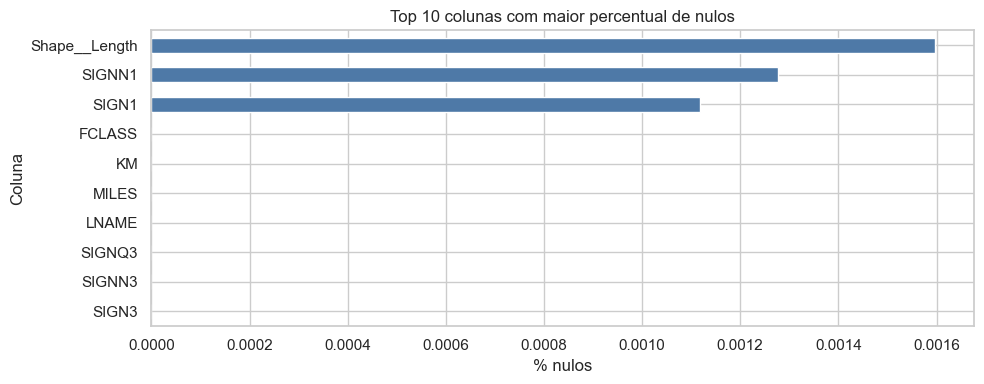

Resumo de unicidade de chaves/códigos:
 - ROUTE_ID: 34,219 valores únicos
 - RECID: 626,349 valores únicos
 - OBJECTID: 626,366 valores únicos
 - FAC_ID: 1,217 valores únicos
 - LRSKEY: 32,590 valores únicos


In [34]:
faltantes = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename('pct_nulos')
      .to_frame()
)

display(faltantes.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
(faltantes.head(10)
 .sort_values('pct_nulos')
 .plot(kind='barh', y='pct_nulos', legend=False, ax=ax, color='#4e79a7'))
ax.set_title('Top 10 colunas com maior percentual de nulos')
ax.set_xlabel('% nulos')
ax.set_ylabel('Coluna')
plt.tight_layout()
plt.show()

print('Resumo de unicidade de chaves/códigos:')
for col in ['ROUTE_ID', 'RECID', 'OBJECTID', 'FAC_ID', 'LRSKEY']:
    if col in df.columns:
        print(f' - {col}: {df[col].nunique():,} valores únicos')

## 1) Extensão por categoria funcional (`F_SYSTEM`)

Mapeamento de referência comum:

- `1`: Interstate - Interestadual
- `2`: Other Freeways and Expressways - Outras Rodovias e Vias Expressas
- `3`: Other Principal Arterial - Outras Arteriais Principais
- `4`: Minor Arterial - Arterial Secundária
- `5`: Major Collector - Coletora Principal
- `6`: Minor Collector - Coletora Secundária
- `7`: Local
- `0`: sem classificação/indefinido

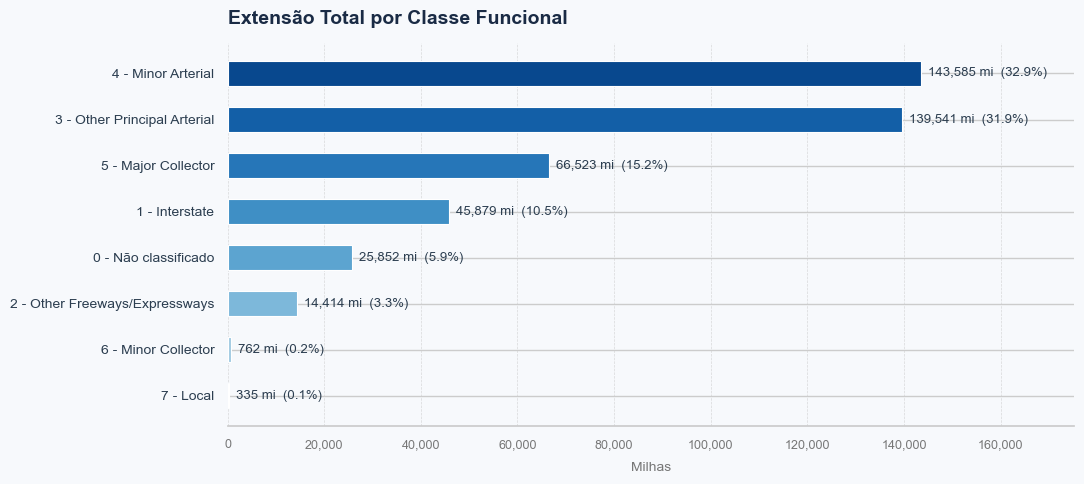

In [93]:
# ── Preparação: extensão por F_SYSTEM ─────────────────────────────────
# Mapa de referência (FHWA) frequentemente usado para F_SYSTEM
f_system_labels = {
    1: 'Interstate',
    2: 'Other Freeways & Expressways',
    3: 'Other Principal Arterial',
    4: 'Minor Arterial',
    5: 'Major Collector',
    6: 'Minor Collector',
    7: 'Local',
    0: 'Indefinido'
}

extensao_fsystem = (
    df.groupby('F_SYSTEM', dropna=False)
      .agg(MILES=('MILES', 'sum'), KM=('KM', 'sum'))
      .assign(classe=lambda d: d.index.map(lambda x: f_system_labels.get(int(x), 'Outra')))
      .sort_values('MILES', ascending=False)
)
extensao_fsystem['pct_miles'] = 100 * extensao_fsystem['MILES'] / extensao_fsystem['MILES'].sum()


# ── Plot ─────────────────────────────────────────────────────────────
BG     = '#F7F9FC'
DARK   = '#1A2B45'
MID    = '#2C3E50'
SUBTLE = '#777777'
GRID   = '#CCCCCC'

plot_df = extensao_fsystem.reset_index().sort_values('MILES', ascending=True)
palette = sns.color_palette("Blues", len(plot_df) + 2)[2:]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    plot_df['classe'],
    plot_df['MILES'],
    color=palette,
    height=0.55,
    edgecolor='white',
    linewidth=0.8
)

ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for bar, val, pct in zip(bars, plot_df['MILES'], plot_df['pct_miles']):
    ax.text(
        bar.get_width() + plot_df['MILES'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f} mi  ({pct:.1f}%)',
        va='center', ha='left',
        fontsize=9.5, color=MID, fontweight='500'
    )

ax.set_title('Extensão Total por Classe Funcional', fontsize=14, fontweight='bold',
             color=DARK, pad=14, loc='left')
ax.set_xlabel('Milhas', fontsize=10, color=SUBTLE, labelpad=8)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10, colors=MID)
ax.tick_params(axis='x', labelsize=9,  colors=SUBTLE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(right=plot_df['MILES'].max() * 1.22)

plt.tight_layout()
plt.show()

## 2) Densidade rodoviária por estado

Nesta base, calculamos **extensão absoluta** por estado. Para densidade real (km por área), recomenda-se integrar a área territorial por estado (Census).

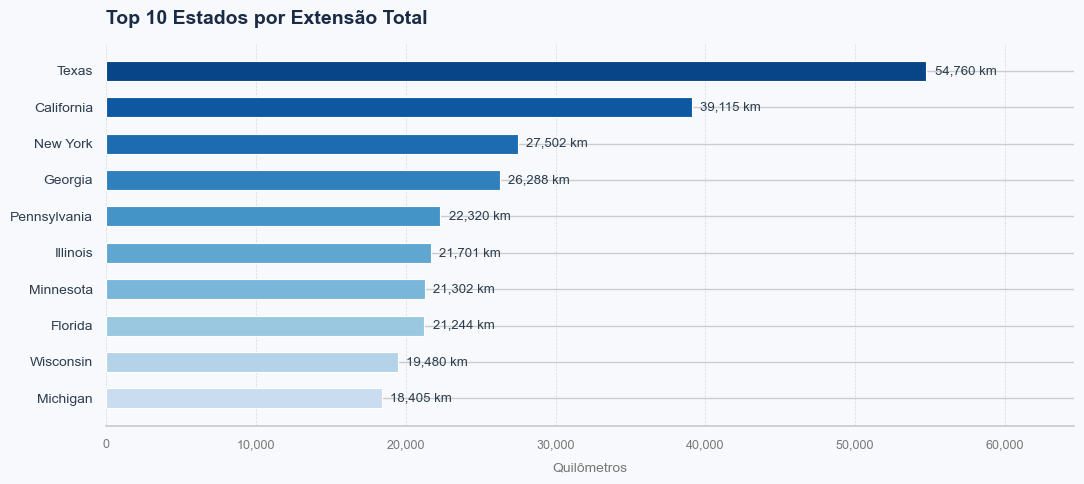

In [91]:
# ── Preparação: extensão por estado (STFIPS) ─────────────────────────
extensao_estado = (
    df.groupby('STFIPS', dropna=False)
      .agg(MILES=('MILES', 'sum'), KM=('KM', 'sum'))
      .sort_values('KM', ascending=False)
)

extensao_estado_nome = (
    extensao_estado
    .reset_index()
    .assign(estado=lambda d: d['STFIPS'].map(fips_to_state).fillna('Desconhecido'))
    .sort_values('KM', ascending=False)
)


# ── Plot ─────────────────────────────────────────────────────────────
BG     = '#F7F9FC'
DARK   = '#1A2B45'
MID    = '#2C3E50'
SUBTLE = '#777777'
GRID   = '#CCCCCC'

top10_estados = extensao_estado_nome.head(10).sort_values('KM', ascending=True)
palette = sns.color_palette("Blues", len(top10_estados) + 2)[2:]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    top10_estados['estado'],
    top10_estados['KM'],
    color=palette,
    height=0.55,
    edgecolor='white',
    linewidth=0.8
)

ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for bar, val in zip(bars, top10_estados['KM']):
    ax.text(
        bar.get_width() + top10_estados['KM'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f} km',
        va='center', ha='left',
        fontsize=9.5, color=MID, fontweight='500'
    )

ax.set_title('Top 10 Estados por Extensão Total', fontsize=14, fontweight='bold',
             color=DARK, pad=14, loc='left')
ax.set_xlabel('Quilômetros', fontsize=10, color=SUBTLE, labelpad=8)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10, colors=MID)
ax.tick_params(axis='x', labelsize=9,  colors=SUBTLE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(right=top10_estados['KM'].max() * 1.18)

plt.tight_layout()
plt.show()

## 3) Identificação de corredores principais (`SIGN1`/`SIGNT1`)

Nesta etapa, usamos os campos de sinalização para identificar o tipo de corredor:

- `SIGNT1` indica o **sistema da rota**.
  - `I` = **Interstate Highway** (rede interestadual de alta capacidade, padrão federal)
  - `US` = **U.S. Highway** (rede federal tradicional, geralmente conectando cidades/regiões)
  - `S` = **State Highway** (rodovia estadual)
- `SIGN1` traz o identificador da rota (ex.: `I95`, `US1`, `S65`).

Para o recorte de corredores principais, vamos considerar `SIGNT1` em `{I, US}` e comparar sua participação em quantidade de trechos e extensão total.

,SIGNT1_NORM,tipo,trechos,MILES,pct_trechos,pct_miles
1,S,State Highway,250111,"212,938.115",39.930,48.739
0,I,Interstate,96892,"46,652.531",15.469,10.678


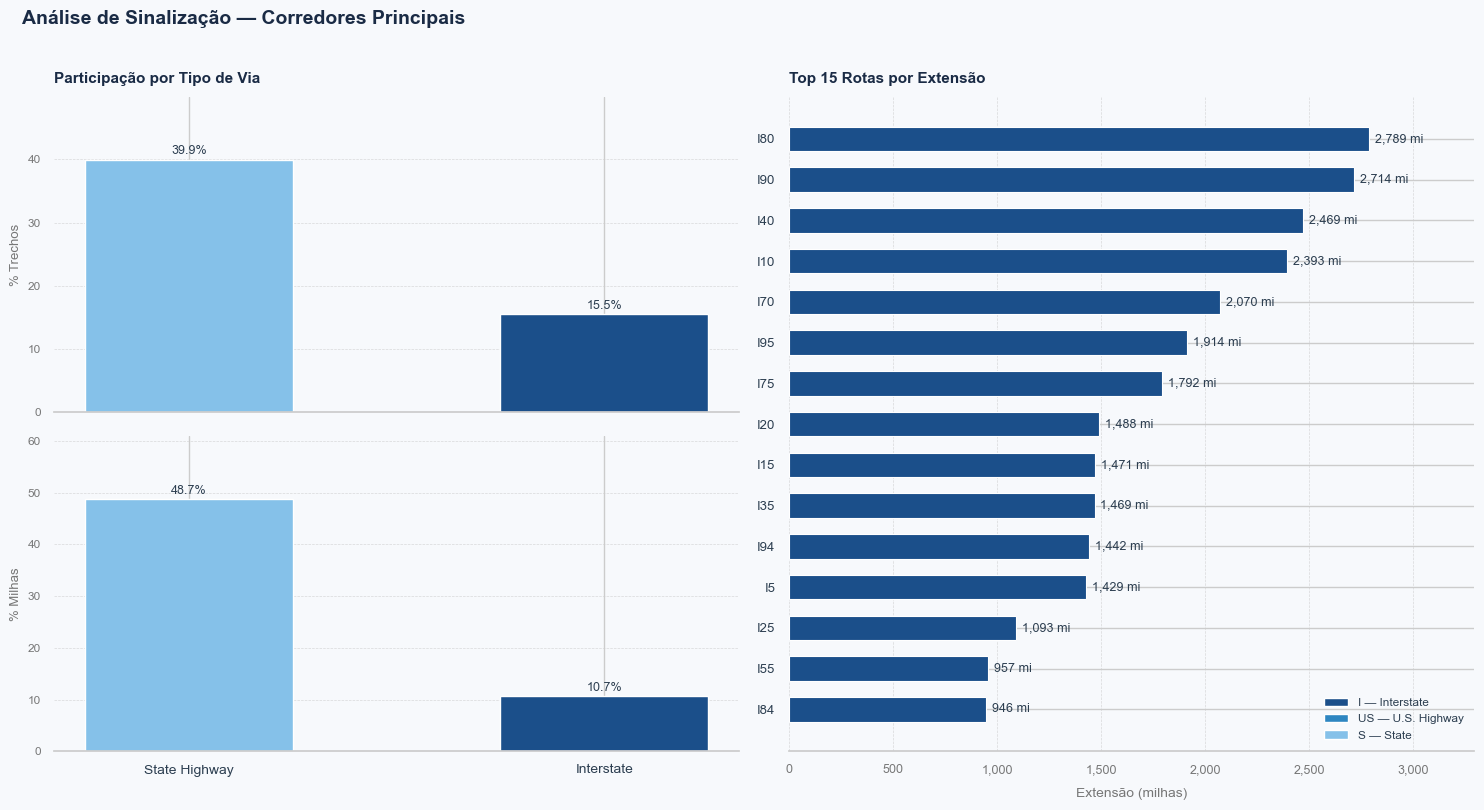

In [81]:
tipos_principais = {'I', 'US'}
tipos_explicacao = {'I': 'Interstate', 'US': 'U.S. Highway', 'S': 'State Highway'}

# Normaliza SIGNT1 para evitar diferenças de caixa/espaços
sign_norm = df['SIGNT1'].astype(str).str.upper().str.strip()

# Resumo por tipo de sinalização
resumo_sinalizacao = (
    df.assign(SIGNT1_NORM=sign_norm)
      .loc[lambda d: d['SIGNT1_NORM'].isin(tipos_explicacao)]
      .groupby('SIGNT1_NORM', dropna=False)
      .agg(trechos=('SIGNT1_NORM', 'size'), MILES=('MILES', 'sum'), KM=('KM', 'sum'))
      .reset_index()
)
resumo_sinalizacao['tipo'] = resumo_sinalizacao['SIGNT1_NORM'].map(tipos_explicacao)
resumo_sinalizacao['pct_trechos'] = 100 * resumo_sinalizacao['trechos'] / len(df)
resumo_sinalizacao['pct_miles'] = 100 * resumo_sinalizacao['MILES'] / df['MILES'].sum()

display(
    resumo_sinalizacao[['SIGNT1_NORM', 'tipo', 'trechos', 'MILES', 'pct_trechos', 'pct_miles']]
    .sort_values('MILES', ascending=False)
)

# Corredores principais (I/US)
corredores = df.loc[sign_norm.isin(tipos_principais)].copy()
share_trechos = len(corredores) / len(df)
share_milhas = corredores['MILES'].sum() / df['MILES'].sum()

# Top rotas (SIGN1) dentro de cada tipo principal
rotas_top = (
    corredores.assign(SIGNT1=sign_norm)
      .groupby(['SIGNT1', 'SIGN1'], dropna=False)
      .agg(MILES=('MILES', 'sum'), trechos=('SIGN1', 'size'))
      .reset_index()
      .sort_values('MILES', ascending=False)
      .head(15)
)


# ── Paleta executiva ──────────────────────────────────────────────
BG      = '#F7F9FC'
DARK    = '#1A2B45'
MID     = '#2C3E50'
SUBTLE  = '#777777'
GRID    = '#CCCCCC'

TYPE_COLORS = {
    'I':  '#1B4F8A',   # Interstate   — azul escuro
    'US': '#2E86C1',   # US Highway   — azul médio
    'S':  '#85C1E9',   # State        — azul claro
}


fig = plt.figure(figsize=(15, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Análise de Sinalização — Corredores Principais',
             fontsize=14, fontweight='bold', color=DARK, x=0.02, ha='left', y=1.01)

# 2 linhas na coluna esquerda, 1 bloco na coluna direita
ax_top = plt.subplot2grid((2, 2), (0, 0))   # % Trechos
ax_bot = plt.subplot2grid((2, 2), (1, 0))   # % Milhas
ax2    = plt.subplot2grid((2, 2), (0, 1), rowspan=2)  # Top 15 rotas

rs = resumo_sinalizacao.sort_values('MILES', ascending=False)
tipos  = rs['tipo'].tolist()
colors = [TYPE_COLORS.get(t, '#AEB6BF') for t in rs['SIGNT1_NORM']]
x      = range(len(rs))

for ax, col, label in [
    (ax_top, 'pct_trechos', '% Trechos'),
    (ax_bot, 'pct_miles',   '% Milhas'),
]:
    ax.set_facecolor(BG)
    bars = ax.bar(x, rs[col], color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, rs[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color=MID)
    ax.set_xticks(list(x))
    ax.set_xticklabels(tipos if ax == ax_bot else ['']*len(tipos),
                       fontsize=10, color=MID)
    ax.set_ylabel(label, fontsize=9.5, color=SUBTLE)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(axis='x', colors=MID)
    ax.tick_params(axis='y', colors=SUBTLE, labelsize=8.5)
    ax.set_ylim(0, rs[col].max() * 1.25)

ax_top.set_title('Participação por Tipo de Via', fontsize=11, fontweight='bold',
                 color=DARK, loc='left', pad=10)

# PAINEL DIREITO — Top 15 rotas

ax2.set_facecolor(BG)
rt = rotas_top.sort_values('MILES', ascending=True)
bar_colors = [TYPE_COLORS.get(t, '#AEB6BF') for t in rt['SIGNT1']]

bars = ax2.barh(rt['SIGN1'].astype(str), rt['MILES'],
                color=bar_colors, height=0.6, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, rt['MILES']):
    ax2.text(bar.get_width() + rt['MILES'].max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f} mi', va='center', fontsize=9, color=MID)

ax2.set_title('Top 15 Rotas por Extensão', fontsize=11, fontweight='bold',
              color=DARK, loc='left', pad=10)
ax2.set_xlabel('Extensão (milhas)', fontsize=10, color=SUBTLE, labelpad=8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.xaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.spines['bottom'].set_color(GRID)
ax2.tick_params(axis='y', labelsize=9.5, colors=MID)
ax2.tick_params(axis='x', labelsize=9, colors=SUBTLE)
ax2.set_xlim(right=rt['MILES'].max() * 1.18)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k + ' — ' + {'I':'Interstate','US':'U.S. Highway','S':'State'}.get(k,''))
              for k, v in TYPE_COLORS.items()]
ax2.legend(handles=legend_els, fontsize=8.5, framealpha=0, labelcolor=MID, loc='lower right')

plt.tight_layout()
plt.show()


## 4) Estudo do NHS (`NHS`)

NHS significa *National Highway System* — o Sistema Nacional de Rodovias dos EUA. É uma rede de estradas consideradas estratégicas para o país, classificadas em diferentes categorias conforme sua função e relevância nacional.

### NHS 0 — Não-NHS

Rodovias fora do Sistema Nacional de Rodovias.

**Interpretação:** mais de 3 em cada 5 milhas da malha catalogada no NHPN **não** integram o NHS. Isso representa a vasta rede de rodovias estaduais, coletoras e locais que complementam os corredores federais.

### NHS 7 — NHS Estratégico (STRAHNET)

*Strategic Highway Network* (STRAHNET), com foco em suporte a mobilizações militares e defesa nacional.

**Interpretação:** é o segundo maior grupo da rede, acima inclusive do NHS Principal. Inclui rotas designadas pelo Departamento de Defesa como essenciais para movimentação de tropas e equipamentos. Muitas coincidem com Interstates, mas também existem corredores estratégicos não interestaduais.

### NHS 1 — NHS Principal

*National Highway System*, rede principal de interesse nacional.

**Interpretação:** é o núcleo do sistema federal de rodovias. Concentra fluxos de comércio interestadual e conectividade entre grandes centros urbanos. Embora represente cerca de 11% da extensão, tende a concentrar alta prioridade de financiamento federal.

### NHS 3 — NHS Conexão

Rotas de conexão entre o NHS e terminais, portos e instalações estratégicas.

**Interpretação:** são rotas de acesso que conectam o NHS principal a aeroportos, portos marítimos, terminais ferroviários e instalações militares. Têm papel relevante para a logística de última milha do sistema federal.



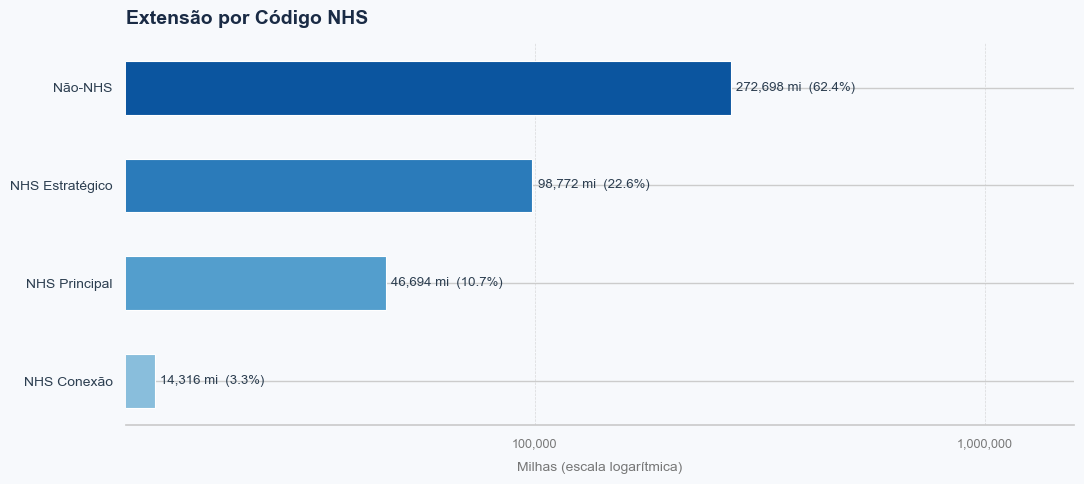

In [88]:
# ── Preparação: extensão por código NHS ─────────────────────────────
nhs_ext = (
    df.groupby('NHS', dropna=False)
      .agg(MILES=('MILES', 'sum'), trechos=('NHS', 'size'))
      .sort_values('MILES', ascending=False)
)
nhs_ext['pct_miles'] = 100 * nhs_ext['MILES'] / nhs_ext['MILES'].sum()

nhs_labels = {
    0: '0 — Não-NHS',
    1: '1 — NHS Principal',
    3: '3 — NHS Conexão',
    7: '7 — NHS Estratégico (STRAHNET)'
}

nhs_plot = (
    nhs_ext.reset_index()
           .assign(label=lambda d: d['NHS'].map(lambda x: nhs_labels.get(int(x), f"{int(x)} — Outro")))
)


# ── Plot ─────────────────────────────────────────────────────────────
BG     = '#F7F9FC'
DARK   = '#1A2B45'
MID    = '#2C3E50'
SUBTLE = '#777777'
GRID   = '#CCCCCC'

nhs_plot_sorted = nhs_plot.sort_values('MILES', ascending=True).tail(4)

palette = sns.color_palette("Blues", len(nhs_plot_sorted) + 2)[2:]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    nhs_plot_sorted['label'],
    nhs_plot_sorted['MILES'],
    color=palette,
    height=0.55,
    edgecolor='white',
    linewidth=0.8
)

ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
ax.set_axisbelow(True)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for bar, val, pct in zip(bars, nhs_plot_sorted['MILES'], nhs_plot_sorted['pct_miles']):
    ax.text(
        bar.get_width() * 1.03,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f} mi  ({pct:.1f}%)',
        va='center', ha='left',
        fontsize=9.5, color=MID, fontweight='500'
    )

ax.set_title('Extensão por Código NHS', fontsize=14, fontweight='bold',
             color=DARK, pad=14, loc='left')
ax.set_xlabel('Milhas (escala logarítmica)', fontsize=10, color=SUBTLE, labelpad=8)
ax.tick_params(axis='y', labelsize=10, colors=MID)
ax.tick_params(axis='x', labelsize=9,  colors=SUBTLE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(right=ax.get_xlim()[1] * 5)

plt.tight_layout()
plt.show()


## 6) Visualização geoespacial (agregada por estado)

Este CSV não traz geometria linha a linha (WKT/lat-lon), mas podemos mapear a intensidade por estado usando o nome (ou a sigla) de cada estado nas visualizações.

In [65]:
# Mapa coroplético por estado (extensão em KM)
# Requer plotly: pip install plotly

estado_mapa = extensao_estado.reset_index().copy()
estado_mapa['state_abbr'] = estado_mapa['STFIPS'].map(fips_to_abbr)
estado_mapa['state_name'] = estado_mapa['STFIPS'].map(fips_to_state)
estado_mapa = estado_mapa.dropna(subset=['state_abbr'])

try:
    import plotly.express as px

    fig = px.choropleth(
        estado_mapa,
        locations='state_abbr',
        locationmode='USA-states',
        color='KM',
        scope='usa',
        hover_name='state_name',
        hover_data={'state_abbr': True, 'KM': ':.2f', 'MILES': ':.2f'},
        title='Extensão rodoviária total por estado (KM)'
    )
    
    fig.show()
except Exception as e:
    print('Plotly indisponível no ambiente atual. Erro:', e)
    print('Instale com: pip install plotly')
    
    
    

## 7) Análise Rural vs. Urbano (`URBAN_CODE` / `RUCODE`)

Consideramos `URBAN_CODE == 99999` como **rural** e os demais valores como **urbano**. A análise abaixo compara quantidade de segmentos, extensão total e extensão média por segmento, além de cruzar com `F_SYSTEM` para identificar classes dominantes em cada contexto territorial.

,area_tipo,classe,segmentos,miles_total,pct_miles_area
4,Rural,4 - Minor Arterial,95647,"123,078.711",39.879
3,Rural,3 - Other Principal Arterial,79372,"85,861.237",27.820
5,Rural,5 - Major Collector,58695,"63,371.343",20.533
1,Rural,1 - Interstate,36747,"29,613.449",9.595
2,Rural,2 - Other Freeways/Expressways,3866,"3,965.820",1.285
0,Rural,0 - Não classificado,2277,"1,834.195",0.594
6,Rural,6 - Minor Collector,169,601.580,0.195
7,Rural,7 - Local,350,301.835,0.098
11,Urbano,3 - Other Principal Arterial,173998,"53,679.632",41.851
8,Urbano,0 - Não classificado,16113,"24,018.260",18.726


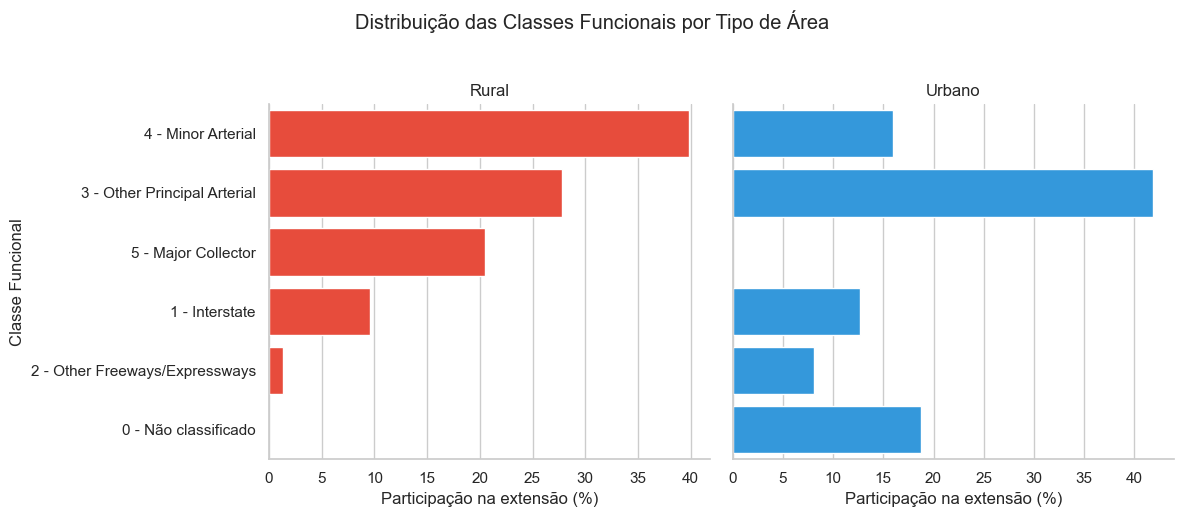

In [89]:
# Garante que o mapeamento exista mesmo se a célula (F_SYSTEM) não tiver rodado antes
if 'f_system_labels' not in globals():
    f_system_labels = {
        1: 'Interstate',
        2: 'Other Freeways & Expressways',
        3: 'Other Principal Arterial',
        4: 'Minor Arterial',
        5: 'Major Collector',
        6: 'Minor Collector',
        7: 'Local',
        0: 'Indefinido'
    }


df_ru = df.copy()
df_ru['area_tipo'] = np.where(df_ru['URBAN_CODE'] == 99999, 'Rural', 'Urbano')

df_ru_resumo = (
    df_ru.groupby('area_tipo', dropna=False)
    .agg(segmentos=('area_tipo', 'size'), miles_total=('MILES', 'sum'))
    .reset_index()
)
df_ru_resumo['pct_segmentos'] = 100 * df_ru_resumo['segmentos'] / len(df_ru)
df_ru_resumo['miles_por_segmento'] = df_ru_resumo['miles_total'] / df_ru_resumo['segmentos']


# Cruzamento com classe funcional
ru_fsystem = (
    df_ru.groupby(['area_tipo', 'F_SYSTEM'], dropna=False)
    .agg(segmentos=('F_SYSTEM', 'size'), miles_total=('MILES', 'sum'))
    .reset_index()
)
ru_fsystem['classe'] = ru_fsystem['F_SYSTEM'].map(f_system_labels).fillna('Outra')
ru_fsystem['pct_miles_area'] = ru_fsystem['miles_total'] / ru_fsystem.groupby('area_tipo')['miles_total'].transform('sum') * 100

display(
    ru_fsystem.sort_values(['area_tipo', 'miles_total'], ascending=[True, False])
    .groupby('area_tipo', group_keys=False)
    .head(8)[['area_tipo', 'classe', 'segmentos', 'miles_total', 'pct_miles_area']]
)

plot_ru = (
    ru_fsystem.sort_values(['area_tipo', 'miles_total'], ascending=[True, False])
    .groupby('area_tipo', group_keys=False)
    .head(5)
    .copy()
)

# bar plot

g = sns.FacetGrid(plot_ru, col='area_tipo', sharex=False, height=5, aspect=1.2)
g.map_dataframe(
    sns.barplot, x='pct_miles_area', y='classe',
    hue='classe', legend=False,
    palette='tab10'
)
g.set_axis_labels('Participação na extensão (%)', 'Classe Funcional')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Distribuição das Classes Funcionais por Tipo de Área', y=1.03)

# Recolore cada painel com a cor da sua área — APÓS criar o grid
cores = {'Rural': '#e74c3c', 'Urbano': '#3498db'}
for ax, area in zip(g.axes.flat, plot_ru['area_tipo'].unique()):
    for patch in ax.patches:
        patch.set_facecolor(cores[area])

plt.tight_layout()
plt.show()



## 8) Análise STRAHNET — Rede Estratégica Militar (`STRAHNET`)

A análise abaixo mede a cobertura estratégica por estado e verifica a sobreposição com corredores `Interstate` (`SIGNT1 == I`), para identificar onde há participação estratégica fora da malha interestadual.

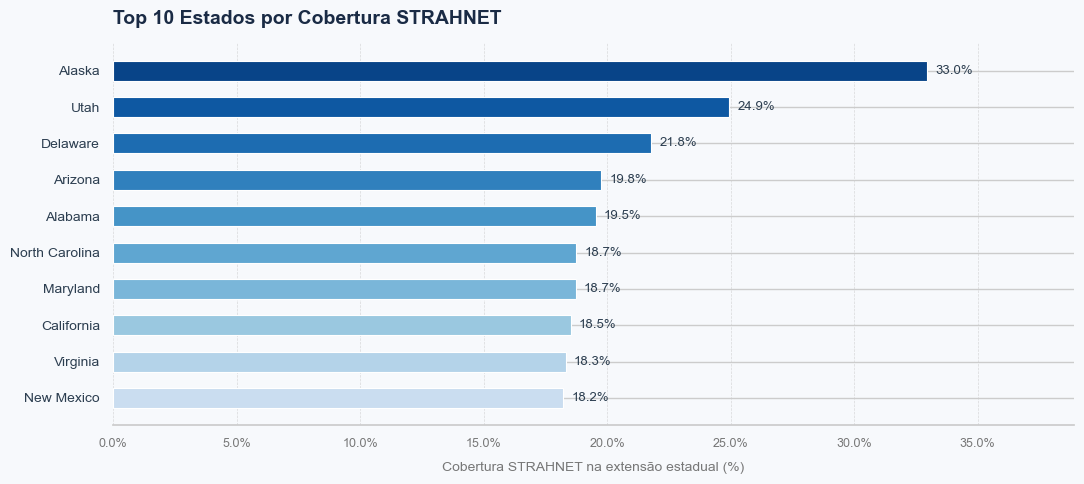

In [94]:
# ── Preparação: STRAHNET por estado ─────────────────────────────────
# Em geral, STRAHNET == 1 indica participação; aqui tratamos >0 como “pertence”.
df_st = df.copy()
df_st['is_strahnet'] = df_st['STRAHNET'].fillna(0).astype(float) > 0

strahnet_estado = (
    df_st.groupby('STFIPS', dropna=False)
         .agg(
             miles_total=('MILES', 'sum'),
             miles_strahnet=('MILES', lambda s: s[df_st.loc[s.index, 'is_strahnet']].sum())
         )
         .reset_index()
)
strahnet_estado['pct_miles_strahnet'] = 100 * strahnet_estado['miles_strahnet'] / strahnet_estado['miles_total']
strahnet_estado['estado'] = strahnet_estado['STFIPS'].map(fips_to_state).fillna('Desconhecido')


# ── Plot ─────────────────────────────────────────────────────────────
BG     = '#F7F9FC'
DARK   = '#1A2B45'
MID    = '#2C3E50'
SUBTLE = '#777777'
GRID   = '#CCCCCC'

plot_st = (strahnet_estado
           .sort_values('pct_miles_strahnet', ascending=False)
           .head(10)
           .sort_values('pct_miles_strahnet', ascending=True))
palette = sns.color_palette("Blues", len(plot_st) + 2)[2:]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(
    plot_st['estado'],
    plot_st['pct_miles_strahnet'],
    color=palette,
    height=0.55,
    edgecolor='white',
    linewidth=0.8
)

ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color=GRID, alpha=0.7)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

for bar, val in zip(bars, plot_st['pct_miles_strahnet']):
    ax.text(
        bar.get_width() + plot_st['pct_miles_strahnet'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', ha='left',
        fontsize=9.5, color=MID, fontweight='500'
    )

ax.set_title('Top 10 Estados por Cobertura STRAHNET', fontsize=14, fontweight='bold',
             color=DARK, pad=14, loc='left')
ax.set_xlabel('Cobertura STRAHNET na extensão estadual (%)', fontsize=10, color=SUBTLE, labelpad=8)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10, colors=MID)
ax.tick_params(axis='x', labelsize=9,  colors=SUBTLE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRID)
ax.set_xlim(right=plot_st['pct_miles_strahnet'].max() * 1.18)

plt.tight_layout()
plt.show()

## 14) Grafo de Conectividade da Rede (`ROUTE_ID` + `BEGMP` / `ENDMP`)

Sem geometria explícita de nós/arestas, aproximamos a topologia linear por rota ordenando os segmentos por `BEGMP`. Com isso, auditamos continuidade por diferença entre o `ENDMP` de um segmento e o `BEGMP` do próximo.

Critérios adotados:
- **Contínuo**: diferença em valor absoluto <= tolerância.
- **Lacuna (gap)**: próximo `BEGMP` > `ENDMP` + tolerância.
- **Sobreposição**: próximo `BEGMP` < `ENDMP` - tolerância.
- **Segmento órfão**: sem continuidade nem com anterior nem com próximo (ou rota com apenas 1 segmento).

,rotas_analisadas,segmentos_analisados,segmentos_orfaos,pct_orfaos,gaps_entre_segmentos,overlaps_entre_segmentos,delta_next_mediano
0,34219,626366,370727,59.187,10004,405354,-1.118


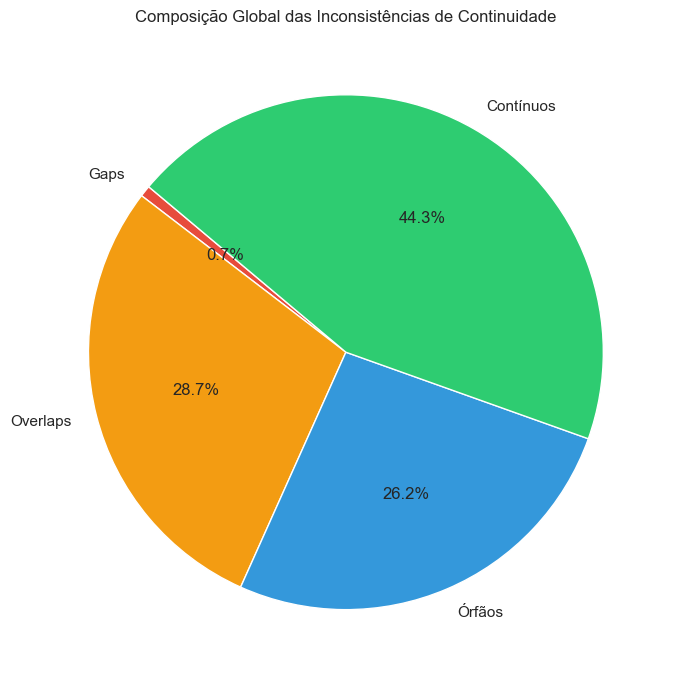

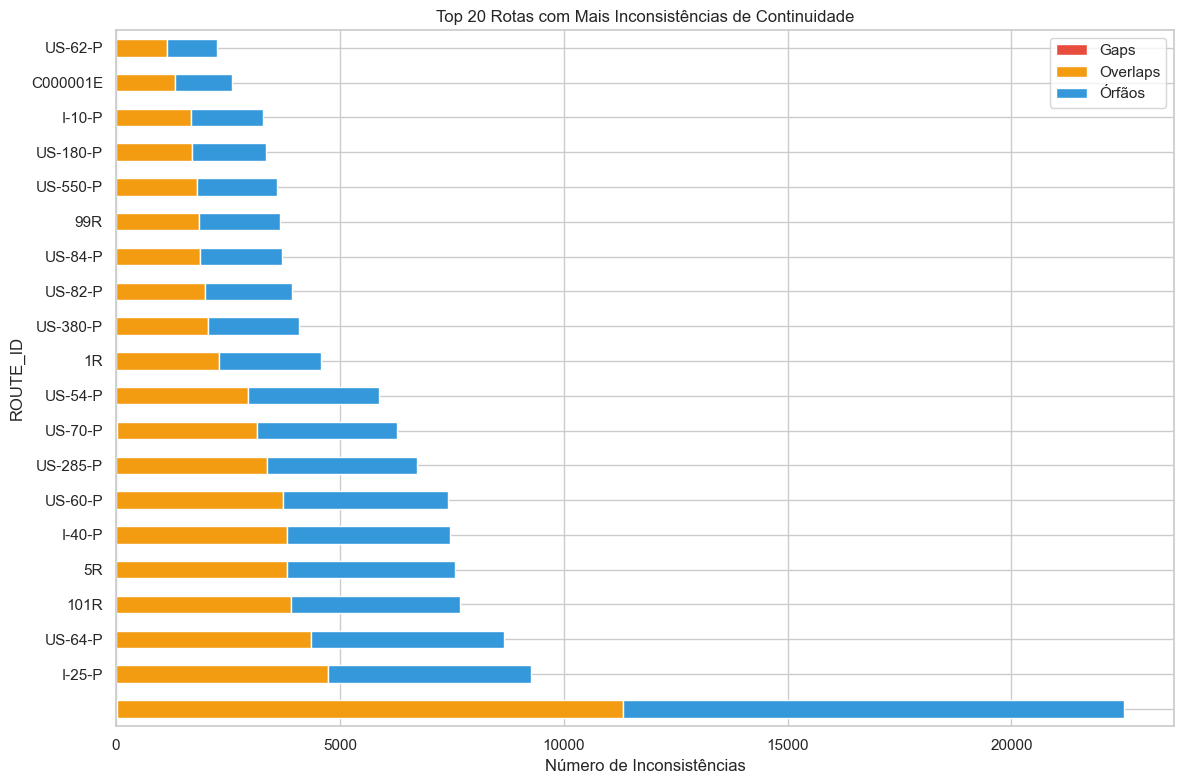

In [98]:
tol = 0.01  # tolerância em milhas de marcador linear (milepost)

grafo = df[['ROUTE_ID', 'BEGMP', 'ENDMP', 'MILES', 'STFIPS']].copy()
grafo = grafo.dropna(subset=['ROUTE_ID', 'BEGMP', 'ENDMP']).copy()
grafo = grafo.sort_values(['ROUTE_ID', 'BEGMP', 'ENDMP']).reset_index(drop=True)

grafo['prev_endmp'] = grafo.groupby('ROUTE_ID')['ENDMP'].shift(1)
grafo['next_begmp'] = grafo.groupby('ROUTE_ID')['BEGMP'].shift(-1)

# Diferenças de continuidade
grafo['delta_prev'] = grafo['BEGMP'] - grafo['prev_endmp']
grafo['delta_next'] = grafo['next_begmp'] - grafo['ENDMP']

grafo['cont_prev'] = grafo['delta_prev'].abs() <= tol
grafo['cont_next'] = grafo['delta_next'].abs() <= tol

grafo['gap_next'] = grafo['delta_next'] > tol
grafo['overlap_next'] = grafo['delta_next'] < -tol

grafo['n_seg_route'] = grafo.groupby('ROUTE_ID')['ROUTE_ID'].transform('size')

grafo['orfao'] = np.where(
    grafo['n_seg_route'] == 1,
    True,
    (~grafo['cont_prev'].fillna(False)) & (~grafo['cont_next'].fillna(False))
)

resumo_conect = pd.DataFrame({
    'rotas_analisadas': [grafo['ROUTE_ID'].nunique()],
    'segmentos_analisados': [len(grafo)],
    'segmentos_orfaos': [int(grafo['orfao'].sum())],
    'pct_orfaos': [100 * grafo['orfao'].mean()],
    'gaps_entre_segmentos': [int(grafo['gap_next'].sum())],
    'overlaps_entre_segmentos': [int(grafo['overlap_next'].sum())],
    'delta_next_mediano': [grafo['delta_next'].dropna().median()]
})
display(resumo_conect)

# Rotas com maior número de inconsistências
route_qc = (
    grafo.groupby('ROUTE_ID', dropna=False)
    .agg(
        segmentos=('ROUTE_ID', 'size'),
        gaps=('gap_next', 'sum'),
        overlaps=('overlap_next', 'sum'),
        orfaos=('orfao', 'sum')
    )
    .reset_index()
)
route_qc['inconsistencias_total'] = route_qc['gaps'] + route_qc['overlaps'] + route_qc['orfaos']

labels = ['Gaps', 'Overlaps', 'Órfãos', 'Contínuos']
valores = [
    resumo_conect['gaps_entre_segmentos'].values[0],
    resumo_conect['overlaps_entre_segmentos'].values[0],
    resumo_conect['segmentos_orfaos'].values[0],
    resumo_conect['segmentos_analisados'].values[0]  # subtrai os demais se quiser
]
plt.figure(figsize=(7, 7))
plt.pie(valores, labels=labels, autopct='%1.1f%%',
        colors=['#e74c3c','#f39c12','#3498db','#2ecc71'], startangle=140)
plt.title('Composição Global das Inconsistências de Continuidade')
plt.tight_layout()

top20 = route_qc.sort_values('inconsistencias_total', ascending=False).head(20)

top20.set_index('ROUTE_ID')[['gaps', 'overlaps', 'orfaos']].plot(
    kind='barh', stacked=True, figsize=(12, 8),
    color=['#e74c3c', '#f39c12', '#3498db']
)
plt.xlabel('Número de Inconsistências')
plt.title('Top 20 Rotas com Mais Inconsistências de Continuidade')
plt.legend(['Gaps', 'Overlaps', 'Órfãos'])
plt.tight_layout()


## 15) Insights reais (gerados a partir da base)

A célula abaixo consolida os principais achados com números calculados diretamente no dataset.

In [43]:
# ── Preparação (defensiva): garante variáveis essenciais ────────────
if 'extensao_fsystem' not in globals():
    f_system_labels = {
        1: 'Interstate',
        2: 'Other Freeways & Expressways',
        3: 'Other Principal Arterial',
        4: 'Minor Arterial',
        5: 'Major Collector',
        6: 'Minor Collector',
        7: 'Local',
        0: 'Indefinido'
    }
    extensao_fsystem = (
        df.groupby('F_SYSTEM', dropna=False)
          .agg(MILES=('MILES', 'sum'), KM=('KM', 'sum'))
          .assign(classe=lambda d: d.index.map(lambda x: f_system_labels.get(int(x), 'Outra')))
          .sort_values('MILES', ascending=False)
    )
    extensao_fsystem['pct_miles'] = 100 * extensao_fsystem['MILES'] / extensao_fsystem['MILES'].sum()

if 'extensao_estado' not in globals():
    extensao_estado = (
        df.groupby('STFIPS', dropna=False)
          .agg(MILES=('MILES', 'sum'), KM=('KM', 'sum'))
          .sort_values('KM', ascending=False)
    )

if 'nhs_ext' not in globals():
    nhs_ext = (
        df.groupby('NHS', dropna=False)
          .agg(MILES=('MILES', 'sum'), trechos=('NHS', 'size'))
          .sort_values('MILES', ascending=False)
    )
    nhs_ext['pct_miles'] = 100 * nhs_ext['MILES'] / nhs_ext['MILES'].sum()

if 'share_trechos' not in globals() or 'share_milhas' not in globals():
    sign_norm = df['SIGNT1'].astype(str).str.upper().str.strip()
    corredores = df.loc[sign_norm.isin({'I', 'US'})]
    share_trechos = len(corredores) / len(df)
    share_milhas = corredores['MILES'].sum() / df['MILES'].sum()

# Consistência KM ↔ MILES
geom = df[['MILES', 'KM']].copy()
geom['MILES_nozero'] = geom['MILES'].replace(0, np.nan)
geom['ratio_km_miles'] = geom['KM'] / geom['MILES_nozero']
geom['erro_abs_km'] = (geom['KM'] - geom['MILES'] * 1.60934).abs()


# ── Insights ─────────────────────────────────────────────────────────
total_miles = df['MILES'].sum()

classe_top = extensao_fsystem.iloc[0]
classe_top_nome = classe_top['classe']
classe_top_pct = classe_top['pct_miles']

estado_top = extensao_estado.head(1).reset_index().iloc[0]
estado_top_nome = fips_to_state.get(int(estado_top['STFIPS']), 'Estado desconhecido')

nhs1_pct = nhs_ext.loc[1, 'pct_miles'] if 1 in nhs_ext.index else np.nan

insights = [
    f"A classe funcional com maior extensão é '{classe_top_nome}', com {classe_top_pct:.2f}% da malha (em milhas).",
    f"O estado com maior extensão total é {estado_top_nome}, com {estado_top['KM']:,.0f} km.",
    f"Trechos de corredores principais (SIGNT1 em I/US) representam {share_trechos:.2%} dos registros e {share_milhas:.2%} da extensão.",
    f"O código NHS == 1 responde por {nhs1_pct:.2f}% da extensão total (em milhas).",
    f"A conversão KM/MILES é muito consistente: mediana {geom['ratio_km_miles'].median():.6f} (esperado 1.60934).",
    f"A consistência MILES/KM é alta: P99 do erro absoluto = {geom['erro_abs_km'].quantile(0.99):.6f} km."
]

print('Principais insights:\n')
for i, texto in enumerate(insights, start=1):
    print(f'{i}. {texto}')

Principais insights:

1. A classe funcional com maior extensao e '4 - Minor Arterial', com 32.87% da malha (em milhas).
2. O estado com maior extensao total e Texas, com 54,760 km.
3. Trechos de corredores principais (SIGNT1 em I/US) representam 15.47% dos registros e 10.68% da extensao.
4. O codigo NHS==1 responde por 10.69% da extensao total em milhas.
5. A conversao KM/MILES e muito consistente: mediana 1.609354 (esperado 1.60934).
6. A consistencia MILES/KM e alta: P99 do erro absoluto = 0.001174 km.


## 16) Recomendações de estudos e aplicações

1. **Priorização de manutenção por hierarquia viária**
   - Cruze `F_SYSTEM` com dados de condição de pavimento/acidentes para priorizar investimento em classes com maior criticidade de serviço.

2. **Planejamento territorial por estado/corredor**
   - Use estados + corredores `I/US` para criar um **índice de criticidade logística** (extensão, conectividade, redundância e exposição a riscos).

3. **Segmentação NHS para funding federal**
   - Separar projetos em `NHS == 1` e demais códigos ajuda a estruturar carteira de projetos alinhada à elegibilidade de recursos federais.

4. **Próximo passo geoespacial (nível trecho)**
   - Integrar o CSV com a camada espacial original (shapefile/geojson) para análises de conectividade de rede, gargalos e simulação de rotas alternativas.

5. **Modelagem preditiva aplicada**
   - Com dados externos (AADT, acidentes, clima, custos), evoluir para modelos de risco por corredor e apoio à decisão multicritério.